# Using Features to Predict the Risk of Heart Disease

The data for this exercise is available here (https://archive.ics.uci.edu/ml/datasets/heart+Disease) (in CSV format).

The dataset contains information from 303 patients who may or may not have heart disease. The features for each patient are:

Column | Description | Feature Type
------------ | -------------------- | ----------------------
Age | Age in years | Numerical
Sex | (1 = male; 0 = female) | Categorical
CP | Chest pain type (0, 1, 2, 3, 4) | Categorical
Trestbpd | Resting blood pressure (in mm Hg on admission) | Numerical
Chol | Serum cholesterol in mg/dl | Numerical
FBS | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false) | Categorical
RestECG | Resting electrocardiogram results (0, 1, 2) | Categorical
Thalach | Maximum heart rate achieved | Numerical
Exang | Exercise-induced angina (1 = yes; 0 = no) | Categorical
Oldpeak | ST depression induced by exercise relative to rest | Numerical
Slope | Slope of the peak exercise ST segment | Numerical
CA | Number of major vessels (0-3) colored by fluoroscopy | Both numerical & categorical
Thal | Normal; fixed; reversible | Categorical
Target | Diagnosis of heart disease (1 = true; 0 = false) | Target

We will create a neural network with 2 layers (1 hidden layer and 1 output layer) to solve this problem.

**Q0**: This is a problem of ???

**Answer:** Supervised (since we know what the model must output on a dataset) binary classification (heart disease or not)



## I. Importing Libraries

---



In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd # A useful library for reading CSV files

from tensorflow.keras import layers # Instead of writing tf.keras.layers.something, we can just write layers.something

## II. Preparing the Data
**QII.1)** Download the data and store it in a pandas DataFrame object.

In [ ]:
file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)
dataframe = dataframe.drop([247,252]) # Remove records 247 and 252, which have specific modalities

**QII.2)** Display the first 10 rows:

In [ ]:
dataframe.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0,normal,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2,normal,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0,normal,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1,reversible,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0,reversible,0


To avoid learning all the properties and methods of the DataFrame object, we will create numpy arrays.

We want to create an array `Y` containing the target variable (output, here `target`) and an array `X` containing the explanatory variables (inputs).

To extract a numpy array from the column `age`, for example, we write:

```python
age = np.array(dataframe.age)
```

**QII.3)** Let's start with the output. Create the variable `Y`:

In [ ]:
Y = np.array(dataframe.target)

**QII.4)** The variable `age` has high values, which may have more influence in the model than other variables like `sex`. It therefore needs to be normalized: subtract the mean `m` and divide by the standard deviation `e`. `norm_v = (v - m) / e`

The mean of a numpy array `a` is written as `np.mean(a)`. The standard deviation is written as `np.std(a)`.

Write the necessary lines to calculate the normalized `age`.

In [ ]:
age = np.array(dataframe.age)
m = np.mean(age)
e = np.std(age)
norm_age = (age - m) / e

**QII.5)** Do the same for all other numerical variables:

`trestbps`, `chol`, `thalach`, `oldpeak`, `slope`, `ca`

To avoid repeating the same code six times, we will first create a `normalize` function that takes a DataFrame column as input and returns the normalized numpy array.

Then apply the function to all these variables.

In [ ]:
def normalize(column):
  m = np.mean(column)
  e = np.std(column)
  return (np.array(column) - m) / e

norm_thestbps = normalize(dataframe.trestbps)
norm_chol = normalize(dataframe.chol)
norm_thalach = normalize(dataframe.thalach)
norm_oldpeak = normalize(dataframe.oldpeak)
norm_slope = normalize(dataframe.slope)
norm_ca = normalize(dataframe.ca)

**QII.6)** Display the first 5 values of `norm_ca`.

You should get:

```python
array([-0.72403274,  2.4808769 ,  1.41257369, -0.72403274, -0.72403274])
```

In [ ]:
norm_ca[:5]

array([-0.72403274,  2.4808769 ,  1.41257369, -0.72403274, -0.72403274])

**QII.7)** The variables `sex`, `fbs`, and `exang` are binary variables (0 or 1) and thus do not need normalization.

Create the numpy arrays `sex`, `fbs`, and `exang`.

In [ ]:
sex = np.array(dataframe.sex)
fbs = np.array(dataframe.fbs)
exang = np.array(dataframe.exang)

**QII.8)** The variables `cp`, `restecg`, and `thal` are categorical variables with more than 2 modalities. These modalities are not necessarily ordered, and it would be inefficient to input them directly into the model. We will use "one-hot encoding": we must create several binary variables, one for each possible modality. All these binary variables will be 0 except the one corresponding to the chosen modality, which will be 1. (See example here: https://en.wikipedia.org/wiki/One-hot)

An example code snippet for performing this operation is provided below:

In [ ]:
classList = ['aa', 'bb', 'cc'] # List of modalities
data = ['aa', 'aa', 'cc', 'bb', 'cc'] # Data in list format
OneHotEncoded = np.zeros((len(data), len(classList)), dtype=float) # Create a matrix of zeros with as many rows as patients and as many columns as possible modalities

for i in range(len(data)): # For each patient
  n = classList.index(data[i]) # Find the position of the modality data[i] in the classList (e.g., classList.index('cc') equals 2)
  OneHotEncoded[i, n] = 1. # Set the modality n for patient i to 1

print(OneHotEncoded)

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]


**Create a function to perform this operation and encode the 3 variables**: `cp`, `restecg`, and `thal`.

In [ ]:
def OneHotEncoding(data, classList):
  OneHotEncoded = np.zeros((len(data), len(classList)), dtype=float) # Create a matrix of zeros with as many rows as patients and as many columns as possible modalities

  for i in range(len(data)): # For each patient
    n = classList.index(data[i]) # Find the position of the modality data[i] in the classList (e.g., classList.index('cc') equals 2)
    OneHotEncoded[i, n] = 1. # Set the modality n for patient i to 1
  return OneHotEncoded

onehot_cp = OneHotEncoding(list(dataframe.cp), [0, 1, 2, 3, 4])
onehot_restecg = OneHotEncoding(list(dataframe.restecg), [0, 1, 2])
onehot_thal = OneHotEncoding(list(dataframe.thal), ['normal', 'fixed', 'reversible'])

**QII.9)** Display the first 5 rows of `onehot_thal`. You should get:

```
array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])
```


In [ ]:
onehot_thal

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0

**QII.10)** We have preprocessed all the input variables. Now we need to concatenate them to create a large array `X`.

The command is `X = np.concatenate((X1, X2, ... Xn), axis=1)`
The variables `Xi` must be 2D arrays with 301 rows and 1 or more columns (1 column for numerical or binary variables, several columns for one-hot encoded variables).

When you type `norm_age.shape`, you will notice it is a 1D array.

What do you need to write to add a second dimension (refer to TP1 if you forgot)?

Create the large array `X` with the preprocessed data.

In [ ]:
X = np.concatenate((
    norm_age[:, np.newaxis],
    sex[:, np.newaxis],
    onehot_cp,
    norm_thestbps[:, np.newaxis],
    norm_chol[:, np.newaxis],
    fbs[:, np.newaxis],
    onehot_restecg,
    norm_thalach[:, np.newaxis],
    exang[:, np.newaxis],
    norm_oldpeak[:, np.newaxis],
    norm_slope[:, np.newaxis],
    norm_ca[:, np.newaxis],
    onehot_thal
), axis=1)

**QII.11)** Verify that `X` has dimensions 301 x 21.

In [ ]:
print(X.shape)

(301, 21)


**QII.12)** Now, we will split the data into three sets: training (60% = 181 samples), validation (20% = 60 samples), and testing (20% = 60 samples).

To do this, we create a random permutation of the patient indices. The first 181 will correspond to the training data, the next 60 to the validation data, and the last 60 to the testing data.

Complete the code below:

In [ ]:
index = np.arange(301) # 0, 1, 2, ..., 300
rng = np.random.default_rng(42) # 42 is a seed so everyone gets the same randomness. Why 42? Because it is the answer to the Ultimate Question of Life, the Universe, and Everything from *The Hitchhiker's Guide to the Galaxy*.
rng.shuffle(index) # `index` is now randomly shuffled, e.g., 209, 238, 61, 254, 166, ...

X_train, Y_train = X[index[:181]], Y[index[:181]]
X_val, Y_val = X[index[181:241]], Y[index[181:241]] # Hint: Do not start indices at 0, or validation data will overlap with training data
X_test, Y_test = X[index[241:]], Y[index[241:]]

**QII.13)** Verify that `X_test` has 60 rows and that the first two are:

```
[[ 0.15826117  1.          0.          0.          0.          0.
   1.          0.01785153 -1.20570916  0.          0.          0.
   1.         -1.93363519  1.          0.89117839  0.65701639  0.34427047
   0.          1.          0.        ]
 [-0.28487011  0.          0.          0.          0.          1.
   0.          0.24409622 -0.97538223  0.          0.          0.
   1.          0.85931287  0.         -0.82503847  0.65701639 -0.72403274
   1.          0.          0.        ]]
```


In [ ]:
print(X_test.shape)
print(X_test[:2])

(60, 21)
[[ 0.15826117  1.          0.          0.          0.          0.
   1.          0.01785153 -1.20570916  0.          0.          0.
   1.         -1.93363519  1.          0.89117839  0.65701639  0.34427047
   0.          1.          0.        ]
 [-0.28487011  0.          0.          0.          0.          1.
   0.          0.24409622 -0.97538223  0.          0.          0.
   1.          0.85931287  0.         -0.82503847  0.65701639 -0.72403274
   1.          0.          0.        ]]


## III. Model Creation

**QIII.1)** Now we will create our model.
First, we create a fully connected layer with 32 neurons and ReLU activation.

Given the type of problem, what should be the number of neurons in the output layer and its activation function?
What will the model output correspond to?

Replace the two `???` placeholders in the code below to reflect your answer.

**Answer:** Binary classification problem => 1 neuron in output with sigmoid activation so that the output represents to the probability of having the heart disease.

In [ ]:
def create_model(): # For clarity, models are often defined in a function, but this is not mandatory
    I = layers.Input(batch_shape=(None, 21)) # 21 corresponds to the number of columns in `X`, None is for the batch size, left flexible
    L1 = layers.Dense(32, activation="relu")(I) # Each layer takes the previous layer as input
    output = layers.Dense(1, activation="sigmoid")(L1)
    return tf.keras.Model(I, output)

model = create_model()

**QIII.2)** To visualize the architecture, execute the following commands:

Why are there 704 weights for the first layer?

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

**Answer:** 32 output x (21 input + 1 bias) = 704 parameters

**QIII.3)** The model must then be compiled. This is where we define the cost function and other metrics used to measure performance.

Since this is a classification problem, the cost function should be cross-entropy. As this is a binary classification problem with only one output (instead of two for general multiclass classification), we specifically use binary cross-entropy.

We also use accuracy (percentage of correct predictions, assuming a 50% probability threshold) as a more interpretable metric.

Additionally, we define the optimizer and learning rate.

In [ ]:
model.compile(
    tf.optimizers.Adam(learning_rate=1e-3),
    "binary_crossentropy",
    metrics=["accuracy"]
)

Finally, we train the model. Here, we use a batch size of 32, which is the default value.

In [ ]:
history = model.fit(
    X_train, Y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, Y_val)
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6039 - loss: 0.6734 - val_accuracy: 0.6500 - val_loss: 0.6374
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7353 - loss: 0.6086 - val_accuracy: 0.6833 - val_loss: 0.5964
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7630 - loss: 0.5781 - val_accuracy: 0.7667 - val_loss: 0.5623
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7363 - loss: 0.5647 - val_accuracy: 0.8000 - val_loss: 0.5311
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8252 - loss: 0.5290 - val_accuracy: 0.8500 - val_loss: 0.5053
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8428 - loss: 0.4975 - val_accuracy: 0.8500 - val_loss: 0.4828
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7846 - loss: 0.5027 - val_accuracy: 0.8500 - val_loss: 0.4626
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8301 - loss: 0.4690 - val_accuracy: 0.8500 - val_loss:

**QIII.4)** What will be the number of batches for the training data? Where can you see this number when you execute the `model.fit(...)` command?

**Answer:** 181 patients divided by batch size 32 so we have 5 batches of 32 patients and one of 21 patients. So 6 batches. We see it at "6/6"

You notice that the accuracy on the validation data increased and then decreased around 40 iterations. The accuracy on the training data, however, only increased.

The loss, which should be minimized, decreased until the end for the training data but not for the validation data.

**QIII.5)** Therefore, there was **overfitting**

We will plot the curves for better visualization:

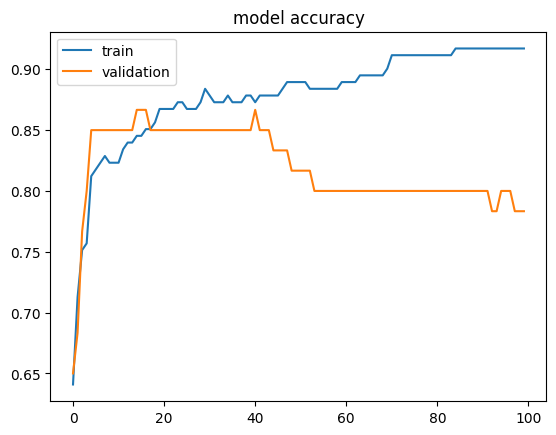

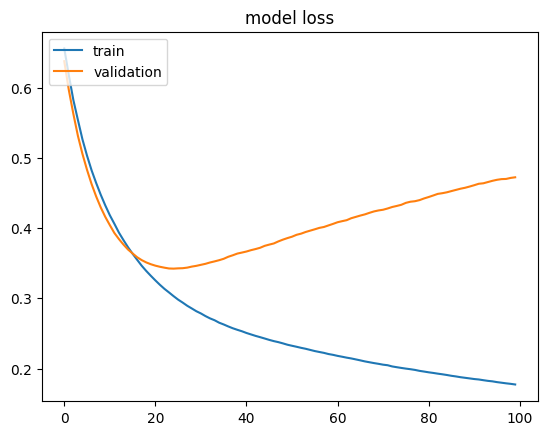

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy']) # The variable `history` is the output of model.fit
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'], loc='upper left')
plt.title('model accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'], loc='upper left')
plt.title('model loss')
plt.show()

III.6) We need to save the weights at the moment when the validation loss is at its minimum. Therefore, we will save whenever a new record is achieved.

In [ ]:
callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="model1/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
model = create_model()
model.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "binary_crossentropy",
              metrics=["accuracy"])
history = model.fit(X_train, Y_train,
          batch_size=32,
          epochs=100,
          validation_data=(X_val, Y_val),
          callbacks=callbacks)

Epoch 1/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.5312 - loss: 0.6927
Epoch 1: val_loss improved from inf to 0.53560, saving model to model1/best-00001-0.5356.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6170 - loss: 0.6552 - val_accuracy: 0.8333 - val_loss: 0.5356
Epoch 2/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7812 - loss: 0.5651
Epoch 2: val_loss improved from 0.53560 to 0.49897, saving model to model1/best-00002-0.4990.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7223 - loss: 0.6013 - val_accuracy: 0.8667 - val_loss: 0.4990
Epoch 3/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6875 - loss: 0.6104
Epoch 3: val_loss improved from 0.49897 to 0.46727, saving model to model1/best-00003-0.4673.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7483 - loss: 0.5710 - val_accuracy: 0.8667 - val_loss: 0.4673
Epoch 4/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6176
Epoch 4: val_loss improved f

**QIII.7)** Load the best model. In my case, it is `best-00054-0.3865.keras`, but you need to replace it with your own (check in the files panel on the left side of your screen).

In [ ]:
model = tf.keras.models.load_model('/content/model1/best-00021-0.3034.keras')


We will re-evaluate on the validation data. Verify that you obtain the same results as during training.

In [ ]:
loss, accuracy = model.evaluate(X_val, Y_val)
print("loss:", loss, " accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8375 - loss: 0.3207 
loss: 0.30344483256340027  accuracy: 0.8500000238418579


**QIII.8)** Perform the same evaluation on the training data. Are the performances better than on the validation data? What is this phenomenon called?

*Due to randomness, this phenomenon might not occur for you. Answer these questions as if the training loss is smaller than the validation loss, even if that's not the case for you.*

In [ ]:
# Command to evaluate on the training data:
loss, accuracy = model.evaluate(X_train, Y_train)






6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8587 - loss: 0.3206 


**Answer:** Here Train Loss 0.32 > Validation loss 0.30 . this is unexpected, often performance on training data is better than validation data due to the evaluation bias : things learnt on training data do not necessarly generalyse well on val data.

We want to see the model's output for each individual in the validation data and compare it with the target variable. The function to apply the model to data is `model.predict`, as shown below.

In [ ]:
Y_val_est = model.predict(X_val)
print(Y_val_est)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.7613319 ]
 [0.10354328]
 [0.03684624]
 [0.08604183]
 [0.1687952 ]
 [0.02852805]
 [0.06069431]
 [0.0754699 ]
 [0.06233085]
 [0.05527318]
 [0.02991355]
 [0.05650702]
 [0.5519651 ]
 [0.6425949 ]
 [0.21015982]
 [0.04047424]
 [0.19645078]
 [0.68637615]
 [0.10009018]
 [0.5132042 ]
 [0.27968854]
 [0.2882464 ]
 [0.2958433 ]
 [0.08390406]
 [0.22351152]
 [0.20532045]
 [0.8526828 ]
 [0.11652539]
 [0.81210196]
 [0.0451539 ]
 [0.66287607]
 [0.08753727]
 [0.62971497]
 [0.08339361]
 [0.53262895]
 [0.07225679]
 [0.1344615 ]
 [0.17549253]
 [0.3047324 ]
 [0.0574426 ]
 [0.3778204 ]
 [0.10515026]
 [0.29347214]
 [0.10727946]
 [0.39745432]
 [0.05404342]
 [0.12403458]
 [0.14877689]
 [0.08631536]
 [0.03506705]
 [0.05413195]
 [0.04941195]
 [0.2637537 ]
 [0.02925728]
 [0.12326334]
 [0.09299519]
 [0.13113679]
 [0.08151406]
 [0.42832714]
 [0.3433301 ]]


**QIII.9)** What exactly do these displayed values represent?

**Answer:** Those number represents the probability estimated by the model to have the disease for each patient.

**QIII.10)** Create a table to display `Y_val` in the first column and `Y_val_est` in the second column.

*Check the shapes of these two arrays beforehand.*

In [ ]:
np.concatenate((Y_val[:, np.newaxis], Y_val_est), axis=1)

array([[0.        , 0.76133192],
       [0.        , 0.10354328],
       [0.        , 0.03684624],
       [0.        , 0.08604183],
       [0.        , 0.1687952 ],
       [0.        , 0.02852805],
       [0.        , 0.06069431],
       [0.        , 0.0754699 ],
       [0.        , 0.06233085],
       [0.        , 0.05527318],
       [0.        , 0.02991355],
       [0.        , 0.05650702],
       [1.        , 0.55196512],
       [1.        , 0.64259487],
       [1.        , 0.21015982],
       [0.        , 0.04047424],
       [0.        , 0.19645078],
       [1.        , 0.68637615],
       [0.        , 0.10009018],
       [0.        , 0.51320422],
       [0.        , 0.27968854],
       [1.        , 0.28824639],
       [1.        , 0.2958433 ],
       [0.        , 0.08390406],
       [0.        , 0.22351152],
       [0.        , 0.20532045],
       [1.        , 0.85268283],
       [0.        , 0.11652539],
       [1.        , 0.81210196],
       [0.        , 0.0451539 ],
       [0.

In [ ]:
print(Y_val.shape)
print(Y_val_est.shape)


(60,)
(60, 1)


**QIII.11)** Now we will try a deeper but narrower architecture. Create:

- A dense layer with 12 neurons and ReLU activation
- A dense layer with 6 neurons and ReLU activation
- A dense layer with 1 neuron and Sigmoid activation

What loss do you obtain? There is always some randomness, so you can train it multiple times to see if, on average, you perform better.

*To avoid overwriting your previous model, name this one `model2` and create the function `create_model2`. Also replace it in the callback.*

In [ ]:
def create_model2(): # For clarity, models are often defined in a function, but this is not mandatory
    I = layers.Input(batch_shape=(None, 21)) # 21 corresponds to the number of columns in `X`, None is for the batch size, left flexible
    L1 = layers.Dense(32, activation="relu")(I) # Each layer takes the previous layer as input
    L2 = layers.Dense(32, activation="relu")(L1) # Each layer takes the previous layer as input
    output = layers.Dense(1, activation="sigmoid")(L2)
    return tf.keras.Model(I, output)

model2 = create_model2()

callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="model2/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
model2.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "binary_crossentropy",
              metrics=["accuracy"])
history = model2.fit(X_train, Y_train,
          batch_size=32,
          epochs=100,
          validation_data=(X_val, Y_val),
          callbacks=callbacks)

Epoch 1/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 3s 728ms/step - accuracy: 0.7188 - loss: 0.6203
Epoch 1: val_loss improved from inf to 0.55423, saving model to model2/best-00001-0.5542.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7335 - loss: 0.6199 - val_accuracy: 0.8000 - val_loss: 0.5542
Epoch 2/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7812 - loss: 0.5967
Epoch 2: val_loss improved from 0.55423 to 0.50903, saving model to model2/best-00002-0.5090.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7718 - loss: 0.5814 - val_accuracy: 0.8167 - val_loss: 0.5090
Epoch 3/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7812 - loss: 0.5386
Epoch 3: val_loss improved from 0.50903 to 0.47395, saving model to model2/best-00003-0.4740.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7741 - loss: 0.5457 - val_accuracy: 0.8167 - val_loss: 0.4740
Epoch 4/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7500 - loss: 0.6043
Epoch 4: val_loss improved f

**QIII.12)** Complete: The best validation loss obtained is 0.33701 at iteration 14

In [ ]:
# To save automatically on google drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def create_model2(): # For clarity, models are often defined in a function, but this is not mandatory
    I = layers.Input(batch_shape=(None, 21)) # 21 corresponds to the number of columns in `X`, None is for the batch size, left flexible
    L1 = layers.Dense(32, activation="relu")(I) # Each layer takes the previous layer as input
    L2 = layers.Dense(32, activation="relu")(L1) # Each layer takes the previous layer as input
    output = layers.Dense(1, activation="sigmoid")(L2)
    return tf.keras.Model(I, output)

model2 = create_model2()

callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="/content/drive/MyDrive/Deep Learning2026/model2/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
model2.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "binary_crossentropy",
              metrics=["accuracy"])
history = model2.fit(X_train, Y_train,
          batch_size=32,
          epochs=100,
          validation_data=(X_val, Y_val),
          callbacks=callbacks)

**QIII.14)** Try to beat your validation data record by varying the activations, the number, or the size of the layers.
*Do not overwrite your previous models. Name them `model3`, `model4`, `model5`, etc., and create functions `create_model3`, `create_model4`, `create_model5`, etc.*

**QIII.15)** Once you are satisfied with your results, perform the final evaluation on the test data to get an unbiased estimate of your model's performance. You must not cheat; evaluate on the test data only after your model is fully validated on the validation data. If you make multiple attempts on the test data and take the best one, your performance estimate will be over-optimistic.

In [ ]:
# For me model1 val loss=0.30 and model2 val loss= 0.33 so the first one is better

model = tf.keras.models.load_model('/content/model1/best-00021-0.3034.keras')
model.evaluate(X_test, Y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7396 - loss: 0.4741 


[0.45314013957977295, 0.75]

Test data response: The best model has a cross-entropy of 0.45 and an accuracy of 75%.

Here as exepected perfomance on test data are poorer than validation data due to evaluation bias. (even if in general there is no so much difference)